In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import tiktoken
from transformers import GPT2Tokenizer, GPT2Model
import torch

import torch
import torch.nn as nn
from torch.nn import functional as F
import math
import inspect
from dataclasses import dataclass

from google.colab import drive
drive.mount('/content/drive')

import json
import pickle
from contextlib import nullcontext

import torch
import tiktoken

#from model import GPT, GPTConfig

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
project_path='/content/drive/My Drive/Nano_GPT'

os.chdir(project_path)
sys.path.append(project_path)

#os.getcwd()
#os.path.exists('model.py')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"using device: {device}")

from model import GPTConfig,GPT

using device: cuda


**Parameter & Hyperparameter**

In [ ]:
@dataclass
class GPTConfig:
    block_size: int = 256
    vocab_size: int = 50304
    n_layer: int = 6
    n_head: int = 6
    n_embd: int = 384
    dropout: float = 0.2     # up from 0.2
    bias: bool = False
    norm_eps: float = 1e-8

warmup_iters = 750            # up from 500
learning_rate = 6e-4           # down from 3e-4
weight_decay = 0.2
beta1 = 0.9
beta2 = 0.99
lr_decay_iters = 15000         # alwaye set to be equal to maximum iteration
min_lr = 6e-5                  # down from 3e-5
grad_clip = 1.0
batch_size = 32
test_size = 0.1
gradient_accumulation_steps = 4
eval_interval = 500
eval_iters = 50

block_size = GPTConfig.block_size
device_type = 'cuda' if 'cuda' in device else 'cpu'  # ← added

**Data Preprocessing**

In [ ]:
# Data Preprocessing
from datasets import load_dataset
from sklearn.model_selection import train_test_split

ROC_stories = load_dataset("mintujupally/ROCStories")
ROC_all = ROC_stories['train'][:]['text']
ROC_train, ROC_val = train_test_split(ROC_all, test_size=test_size, random_state=42)

Repo card metadata block was not found. Setting CardData to empty.


In [ ]:
import re

def clean_story(story):
    story = story.lower()                          # lowercase!
    story = re.sub(r'\s+', ' ', story)
    story = re.sub(r'\.+', '.', story)
    story = story.replace('\u2018', "'").replace('\u2019', "'")
    story = story.strip()
    if story and story[-1] not in '.!?':
        story += '.'
    return story
'''
def normalize_sentences(story):
    sentences = re.split(r'(?<=[.!?])\s+', story.strip())
    sentences = [s.strip() for s in sentences if s.strip()][:5]
    normalized = []
    for s in sentences:
        if s and s[-1] not in '.!?':
            s += '.'
        normalized.append(s)
    return ' '.join(normalized)
'''

def is_valid_story(story):
    sentences = [s.strip() for s in story.split('.') if s.strip()]
    words = story.split()
    if len(sentences) < 4: return False
    if len(words) < 20 or len(words) > 120: return False
    if sum(1 for c in story if c.isupper()) / max(len(story), 1) > 0.3: return False
    return True

def create_corpus(text):
    eos_marker = '<|endoftext|>'
    cleaned = [clean_story(s) for s in text if is_valid_story(s)]
    return eos_marker.join(cleaned) + eos_marker  # EOS only at end, not beginning

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13679/1246894150.py:14: SyntaxWarning: invalid escape sequence '\s'
  sentences = re.split(r'(?<=[.!?])\s+', story.strip())


In [ ]:
'''
def create_corpus(text):
    eos_marker = '<|endoftext|>'
    return ''.join([eos_marker + story + eos_marker for story in text])
'''

def tokenize_corpus(corpus):                  # ✅ fix 2
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token
    token_ids = tokenizer.encode(corpus)      # flat list, no truncation!
    return torch.tensor(token_ids, dtype=torch.long), tokenizer
'''

def tokenize_corpus(corpus):
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token
    # Split into chunks to avoid sequence length warnings
    max_chunk = 1000000  # 1M tokens per chunk
    all_tokens = []
    for i in range(0, len(corpus), max_chunk):
        chunk = corpus[i:i+max_chunk]
        tokens = tokenizer.encode(chunk)
        all_tokens.extend(tokens)
    return torch.tensor(all_tokens, dtype=torch.long), tokenizer
'''

train_corpus = create_corpus(ROC_train)  # augment train only
val_corpus   = create_corpus(ROC_val) # never augment val

train_data, tokenizer = tokenize_corpus(train_corpus)
val_data,   _         = tokenize_corpus(val_corpus)

print(f"train tokens: {len(train_data):,}")
print(f"val tokens:   {len(val_data):,}")

Token indices sequence length is longer than the specified maximum sequence length for this model (3753483 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (416776 > 1024). Running this sequence through the model will result in indexing errors


train tokens: 3,753,483
val tokens:   416,776


In [ ]:
def get_batch(split, batch_size=batch_size):                         # ✅ fix 5
    data = train_data if split == 'train' else val_data
    ix   = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    x    = torch.stack([data[i:i+block_size]     for i in ix])
    y    = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

**Transformer Layer**

In [ ]:
class LayerNorm(nn.Module):
    """ LayerNorm but with an optional bias. PyTorch doesn't support simply bias=False """

    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, input):
        return F.layer_norm(input, self.weight.shape, self.weight, self.bias, 1e-5)

class RMSNorm(nn.Module):
    """
    Alternative to regular layer norm
    Root Mean Square Layer Normalization
    https://arxiv.org/abs/1910.07467

    Simpler than LayerNorm — removes mean centering (re-centering)
    and only keeps the scaling (re-scaling) via RMS
    No bias term needed by design
    """
    def __init__(self, ndim, eps=1e-8):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))  # learnable scale (gamma)
        self.eps    = eps                              # numerical stability

    def forward(self, x):
        # RMS = sqrt(mean(x^2))
        rms    = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).sqrt()
        x_norm = x / rms                              # normalize by RMS
        return self.weight * x_norm                   # scale by learnable gamma

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        # regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        # flash attention make GPU go brrrrr but support is only in PyTorch >= 2.0
        self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        if not self.flash:
            print("WARNING: using slow attention. Flash Attention requires PyTorch >= 2.0")
            # causal mask to ensure that attention is only applied to the left in the input sequence
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        # causal self-attention; Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        if self.flash:
            # efficient attention using Flash Attention CUDA kernels
            y = torch.nn.functional.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.dropout if self.training else 0, is_causal=True)
        else:
            # manual implementation of attention
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side

        # output projection
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        #self.ln_1 = RMSNorm(config.n_embd, eps=config.norm_eps)
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        #self.ln_2 = RMSNorm(config.n_embd, eps=config.norm_eps)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)
        self.dropout = nn.Dropout(config.dropout)  # Add this

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

In [ ]:
class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.vocab_size is not None
        assert config.block_size is not None
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = RMSNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        # with weight tying when using torch.compile() some warnings get generated:
        # "UserWarning: functional_call was passed multiple values for tied weights.
        # This behavior is deprecated and will be an error in future versions"
        # not 100% sure what this is, so far seems to be harmless. TODO investigate
        self.transformer.wte.weight = self.lm_head.weight # https://paperswithcode.com/method/weight-tying

        # init all weights
        self.apply(self._init_weights)
        # apply special scaled init to the residual projections, per GPT-2 paper
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * config.n_layer))

        # report number of parameters
        print("number of parameters: %.2fM" % (self.get_num_params()/1e6,))

    def get_num_params(self, non_embedding=True):
        """
        Return the number of parameters in the model.
        For non-embedding count (default), the position embeddings get subtracted.
        The token embeddings would too, except due to the parameter sharing these
        params are actually used as weights in the final layer, so we include them.
        """
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wpe.weight.numel()
        return n_params

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None,eos_token_id=50256):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)

        # forward the GPT model itself
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        '''
        if targets is not None:
            # if we are given some desired targets also calculate the loss
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            # inference-time mini-optimization: only forward the lm_head on the very last position
            logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
            loss = None
        '''

        if targets is not None:
          logits = self.lm_head(x)
          masked_targets = targets.clone()
          for i in range(b):
              eos_positions = (targets[i] == eos_token_id).nonzero(as_tuple=True)[0]
              if len(eos_positions) > 0:
                  first_eos = eos_positions[0].item()
                  masked_targets[i, first_eos + 1:] = -1
          loss = F.cross_entropy(
              logits.view(-1, logits.size(-1)),
              masked_targets.view(-1),
              ignore_index=-1
          )
        else:
          logits = self.lm_head(x[:, [-1], :])
          loss = None

        return logits, loss

    def crop_block_size(self, block_size):
        # model surgery to decrease the block size if necessary
        # e.g. we may load the GPT2 pretrained model checkpoint (block size 1024)
        # but want to use a smaller block size for some smaller, simpler model
        assert block_size <= self.config.block_size
        self.config.block_size = block_size
        self.transformer.wpe.weight = nn.Parameter(self.transformer.wpe.weight[:block_size])
        for block in self.transformer.h:
            if hasattr(block.attn, 'bias'):
                block.attn.bias = block.attn.bias[:,:,:block_size,:block_size]

    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        override_args = override_args or {} # default to empty dict
        # only dropout can be overridden see more notes below
        assert all(k == 'dropout' for k in override_args)
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        # we can override the dropout rate, if desired
        if 'dropout' in override_args:
            print(f"overriding dropout rate to {override_args['dropout']}")
            config_args['dropout'] = override_args['dropout']
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

    def configure_optimizers(self, weight_decay, learning_rate, betas, device_type):
        # start with all of the candidate parameters
        param_dict = {pn: p for pn, p in self.named_parameters()}
        # filter out those that do not require grad
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
        # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
        print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")
        # Create AdamW optimizer and use the fused version if it is available
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == 'cuda'
        extra_args = dict(fused=True) if use_fused else dict()
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas, **extra_args)
        print(f"using fused AdamW: {use_fused}")

        return optimizer

    def estimate_mfu(self, fwdbwd_per_iter, dt):
        """ estimate model flops utilization (MFU) in units of A100 bfloat16 peak FLOPS """
        # first estimate the number of flops we do per iteration.
        # see PaLM paper Appendix B as ref: https://arxiv.org/abs/2204.02311
        N = self.get_num_params()
        cfg = self.config
        L, H, Q, T = cfg.n_layer, cfg.n_head, cfg.n_embd//cfg.n_head, cfg.block_size
        flops_per_token = 6*N + 12*L*H*Q*T
        flops_per_fwdbwd = flops_per_token * T
        flops_per_iter = flops_per_fwdbwd * fwdbwd_per_iter
        # express our flops throughput as ratio of A100 bfloat16 peak flops
        flops_achieved = flops_per_iter * (1.0/dt) # per second
        flops_promised = 312e12 # A100 GPU bfloat16 peak flops is 312 TFLOPS
        mfu = flops_achieved / flops_promised
        return mfu

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Take a conditioning sequence of indices idx (LongTensor of shape (b,t)) and complete
        the sequence max_new_tokens times, feeding the predictions back into the model each time.
        Most likely you'll want to make sure to be in model.eval() mode of operation for this.
        """
        for _ in range(max_new_tokens):
            # if the sequence context is growing too long we must crop it at block_size
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            # forward the model to get the logits for the index in the sequence
            logits, _ = self(idx_cond)
            # pluck the logits at the final step and scale by desired temperature
            logits = logits[:, -1, :] / temperature
            # optionally crop the logits to only the top k options
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            # apply softmax to convert logits to (normalized) probabilities
            probs = F.softmax(logits, dim=-1)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)
            # append sampled index to the running sequence and continue
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

**Training Loop**

In [ ]:
config=GPTConfig
model = GPT(config).to(device)

number of parameters: 29.94M


In [ ]:
# optimizer
# optimizer = model.configure_optimizers(weight_decay, learning_rate, (beta1, beta2), device_type)
#optimizer.load_state_dict(checkpoint['optimizer'])
#checkpoint = None # free up memory

optimizer = model.configure_optimizers(       # ✅ fix 6 — after model!
    weight_decay = weight_decay,
    learning_rate = learning_rate,
    betas        = (beta1,beta2),
    device_type  = device
)

num decayed parameter tensors: 26, with 30,031,872 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: True


In [ ]:
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y      = get_batch(split)
            with torch.no_grad():    # ← add this
                with ctx:
                  logits, loss   = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out


def get_lr(it):
    if it < warmup_iters:
        return learning_rate * (it + 1) / (warmup_iters + 1)
    if it > lr_decay_iters:
        return min_lr
    decay_ratio = (it - warmup_iters) / (lr_decay_iters - warmup_iters)
    coeff       = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (learning_rate - min_lr)

In [ ]:
# ── Checkpoint Resume Config ───────────────────────────────────────────────
resume_training = True    # set False to train from scratch
additional_iters = 5000   # how many MORE iterations to train
ckpt_path = 'out/ckpt.pt'

# ── Load or Initialize Model ───────────────────────────────────────────────
if resume_training and os.path.exists(ckpt_path):
    print(f"Resuming from checkpoint: {ckpt_path}")
    checkpoint       = torch.load(ckpt_path, map_location=device)

    # restore model
    gptconf          = GPTConfig(**checkpoint['model_args'])
    model            = GPT(gptconf).to(device)
    model.load_state_dict(checkpoint['model'])

    # restore training state
    start_iter       = checkpoint['iter_num'] + 501
    best_val_loss    = checkpoint['val_loss']
    total_iters      = start_iter + additional_iters
    lr_decay_iters   = start_iter+1000

    # restore optimizer
    optimizer = model.configure_optimizers(
        weight_decay = weight_decay,
        learning_rate = learning_rate,
        betas         = (beta1, beta2),
        device_type   = device_type
    )
    optimizer.load_state_dict(checkpoint['optimizer'])

    print(f"Resumed at iter {start_iter} | best val loss: {best_val_loss:.4f}")
    print(f"Training for {additional_iters} more iterations → total: {total_iters}")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

else:
    print("Training from scratch...")
    model         = GPT(GPTConfig).to(device)
    optimizer     = model.configure_optimizers(
        weight_decay  = weight_decay,
        learning_rate = learning_rate,
        betas         = (beta1, beta2),
        device_type   = device_type
    )
    start_iter    = 0
    best_val_loss = float('inf')
    total_iters   = lr_decay_iters   # your default from scratch

# ── Training Loop ──────────────────────────────────────────────────────────
print(f"\nStarting training from step {start_iter} to {total_iters}")

val_loss=[]
train_loss=[]
steps=[]

for iter_num in range(start_iter, total_iters):
    lr = get_lr(iter_num)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    if iter_num % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {iter_num:4d} | train: {losses['train']:.4f} | val: {losses['val']:.4f} | lr: {lr:.6f}")

        val_loss.append(losses['val'])
        train_loss.append(losses['train'])
        steps.append(iter_num)

        # save only when val loss improves
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save({
                'model': model.state_dict(),
                'model_args': {
                    'block_size': GPTConfig.block_size,
                    'vocab_size': GPTConfig.vocab_size,
                    'n_layer':    GPTConfig.n_layer,
                    'n_head':     GPTConfig.n_head,
                    'n_embd':     GPTConfig.n_embd,
                    'dropout':    GPTConfig.dropout,
                    'bias':       GPTConfig.bias,
                },
                'optimizer':  optimizer.state_dict(),
                'iter_num':   iter_num,
                'val_loss':   best_val_loss,
            }, ckpt_path)
            print(f"  → saved best checkpoint (val={best_val_loss:.4f})")


    '''
    optimizer.zero_grad()
    loss.backward()
    if grad_clip != 0.0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()
    '''


    optimizer.zero_grad(set_to_none=True)
    for micro_step in range(gradient_accumulation_steps):
        X, Y = get_batch('train')
        with ctx:
            logits, loss = model(X, Y)
            loss = loss / gradient_accumulation_steps  # ← scale loss down
        loss.backward()  # ← gradients accumulate across micro steps

    # ← clip and step ONCE after all micro steps
    if grad_clip != 0.0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()


print("training done!")


Resuming from checkpoint: out/ckpt.pt
number of parameters: 29.94M
num decayed parameter tensors: 26, with 30,031,872 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: True
Resumed at iter 19501 | best val loss: 3.3956
Training for 5000 more iterations → total: 24501
Model parameters: 30.04M

Starting training from step 19501 to 24501
step 20000 | train: 2.6402 | val: 3.4566 | lr: 0.000061
step 20500 | train: 2.6555 | val: 3.4529 | lr: 0.000060
step 21000 | train: 2.6367 | val: 3.4637 | lr: 0.000060
step 21500 | train: 2.6263 | val: 3.5007 | lr: 0.000060
step 22000 | train: 2.6278 | val: 3.4828 | lr: 0.000060


KeyboardInterrupt: 

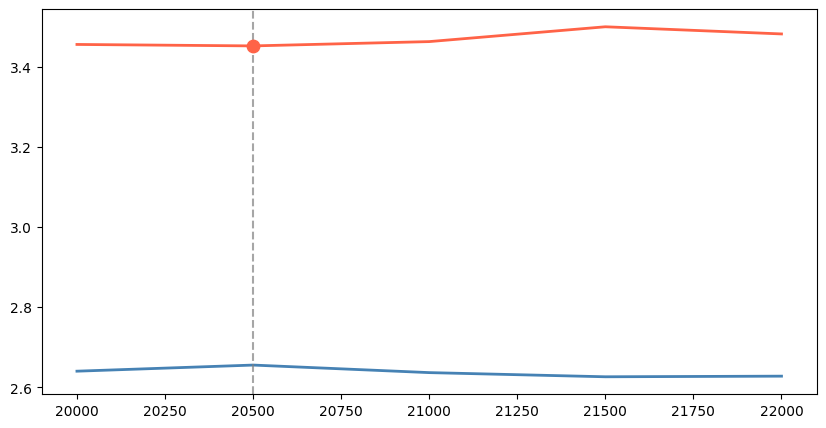

In [ ]:
import matplotlib.pyplot as plt

def plot_losses(train_loss, val_loss, loss_steps):
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(loss_steps, train_loss, label='Train Loss', color='steelblue', linewidth=2)
    ax.plot(loss_steps, val_loss,   label='Val Loss',   color='tomato',    linewidth=2)

    # mark the best val loss point
    best_step = loss_steps[val_loss.index(min(val_loss))]
    best_loss = min(val_loss)
    ax.axvline(x=best_step, color='gray', linestyle='--', alpha=0.7, label=f'Best val step ({best_step})')
    ax.scatter([best_step], [best_loss], color='tomato', zorder=5, s=80)

# call it after training
plot_losses(train_loss, val_loss, steps)

In [ ]:
checkpoint = torch.load('out/ckpt.pt', map_location=device)

# 1. Check the config matches your GPTConfig
print("--- Checkpoint Config ---")
print(checkpoint['model_args'])
# Should show: n_layer=6, n_head=6, n_embd=384, block_size=512 — your small model

# 2. Check parameter count matches
model = GPT(GPTConfig(**checkpoint['model_args']))
model.load_state_dict(checkpoint['model'])
model.to(device)
model.eval()
prompt    = "Emily forgot her umbrella before leaving for work."
input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)  # already on device
eos_id    = tokenizer.encode('<|endoftext|>')[0]

with torch.no_grad():
    output = model.generate(
        idx            = input_ids,
        max_new_tokens = 128,
        temperature    = 0.2,
        top_k          = 100
    )

# cut off at eos token
generated_tokens = output[0].tolist()
if eos_id in generated_tokens:
    generated_tokens = generated_tokens[:generated_tokens.index(eos_id)]

story = tokenizer.decode(generated_tokens, skip_special_tokens=True)
print("\n--- generated story ---")
print(story)

# ── perplexity on the generated story ─────────────────────────────────────
with torch.no_grad():
    gen_tensor = torch.tensor(generated_tokens, dtype=torch.long, device=device)  # ← explicit device

    if len(gen_tensor) < 2:
        print("\n[perplexity] generated sequence too short to evaluate.")
    else:
        x = gen_tensor[:-1].unsqueeze(0).to(device)   # ← .to(device) to be safe
        y = gen_tensor[1:].unsqueeze(0).to(device)    # ← .to(device) to be safe

        _, loss = model(x, y)
        ppl = math.exp(loss.item())

        print("\n--- perplexity on generated story ---")
        print(f"tokens evaluated : {len(gen_tensor) - 1}")
        print(f"avg CE loss      : {loss.item():.4f}")
        print(f"perplexity       : {ppl:.2f}")

--- Checkpoint Config ---
{'block_size': 256, 'vocab_size': 50304, 'n_layer': 6, 'n_head': 6, 'n_embd': 384, 'dropout': 0.2, 'bias': False}
number of parameters: 29.94M

--- generated story ---
Emily forgot her umbrella before leaving for work. she was very late to work. she was late for work. she had to go to work. she had to wait for the rain to come.

--- perplexity on generated story ---
tokens evaluated : 38
avg CE loss      : 1.7548
perplexity       : 5.78


In [ ]:
"""
Evaluate GPT/GPT-2 on a paragraph file and report average loss and perplexity.

Supported input formats:
- .txt: paragraphs separated by one or more blank lines
- .jsonl: one JSON object per line, text field configurable by `json_text_key`
- .json: list[str] or list[dict], text field configurable by `json_text_key`
"""

# -----------------------------------------------------------------------------
# model/load config (same pattern as sample.py)
init_from = 'resume'  # 'resume' or a GPT-2 variant (e.g. 'gpt2-medium')
out_dir = 'out'  # used when init_from == 'resume'
device = 'cuda'  # 'cpu', 'cuda', 'cuda:0', ...
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
compile = False
seed = 1337

# data/eval config
input_file = 'data/rocstories/eval_stories.txt'
input_format = 'txt'  # 'auto' | 'txt' | 'jsonl' | 'json'
json_text_key = 'text'
max_paragraphs = -1  # -1 means all
print_first_n = 3  # preview first N loaded paragraphs


# Temporarily clear sys.argv to prevent configurator.py from misinterpreting notebook arguments
import sys
_orig_argv = sys.argv
sys.argv = [sys.argv[0]]

exec(open('/content/drive/My Drive/Nano_GPT/configurator.py').read())  # allows overrides from CLI / config file

sys.argv = _orig_argv # Restore sys.argv
# -----------------------------------------------------------------------------


def _read_txt_paragraphs(path):
    with open(path, 'r', encoding='utf-8') as f:
        content = f.read()
    parts = content.split('\n\n')
    return [p.strip() for p in parts if p.strip()]


def _read_jsonl_paragraphs(path, text_key):
    paragraphs = []
    with open(path, 'r', encoding='utf-8') as f:
        for ln, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            if isinstance(obj, str):
                text = obj
            elif isinstance(obj, dict):
                if text_key not in obj:
                    raise KeyError(f"Missing key '{text_key}' in JSONL line {ln}")
                text = obj[text_key]
            else:
                raise TypeError(f"Unsupported JSONL value type on line {ln}: {type(obj)}")
            text = text.strip()
            if text:
                paragraphs.append(text)
    return paragraphs


def _read_json_paragraphs(path, text_key):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise TypeError("JSON input must be a list of strings or objects")
    paragraphs = []
    for i, item in enumerate(data):
        if isinstance(item, str):
            text = item
        elif isinstance(item, dict):
            if text_key not in item:
                raise KeyError(f"Missing key '{text_key}' in JSON item index {i}")
            text = item[text_key]
        else:
            raise TypeError(f"Unsupported JSON item type at index {i}: {type(item)}")
        text = text.strip()
        if text:
            paragraphs.append(text)
    return paragraphs


def load_paragraphs(path, fmt, text_key):
    if fmt == 'auto':
        ext = os.path.splitext(path)[1].lower()
        if ext == '.txt':
            fmt = 'txt'
        elif ext == '.jsonl':
            fmt = 'jsonl'
        elif ext == '.json':
            fmt = 'json'
        else:
            fmt = 'txt'

    if fmt == 'txt':
        return _read_txt_paragraphs(path), 'txt'
    if fmt == 'jsonl':
        return _read_jsonl_paragraphs(path, text_key), 'jsonl'
    if fmt == 'json':
        return _read_json_paragraphs(path, text_key), 'json'
    raise ValueError(f"Unsupported input_format: {fmt}")



In [ ]:
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device_type = 'cuda' if 'cuda' in device else 'cpu'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# ── model ────────────────────────────────────────
init_from = 'resume'   # ← load YOUR trained model, not GPT-2
out_dir   = 'out'

if init_from == 'resume':
    ckpt_path  = os.path.join(out_dir, 'ckpt.pt')
    checkpoint = torch.load(ckpt_path, map_location=device)
    gptconf    = GPTConfig(**checkpoint['model_args'])
    model      = GPT(gptconf)
    state_dict = checkpoint['model']
    unwanted_prefix = '_orig_mod.'
    for k, v in list(state_dict.items()):          # ← fixed indentation
        if k.startswith(unwanted_prefix):
            state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
    model.load_state_dict(state_dict)
elif init_from.startswith('gpt2'):
    model = GPT.from_pretrained(init_from, dict(dropout=0.0))
else:
    raise ValueError(f"Unsupported init_from: {init_from}")

model.eval()
model.to(device)
if compile:
    model = torch.compile(model)

# ── tokenizer ───────────────────────────────────────
load_meta = False
if init_from == 'resume' and 'config' in checkpoint and 'dataset' in checkpoint['config']:
    meta_path = os.path.join('data', checkpoint['config']['dataset'], 'meta.pkl')
    load_meta = os.path.exists(meta_path)

if load_meta:
    print(f"Loading meta from {meta_path}...")        # ← fixed indentation
    with open(meta_path, 'rb') as f:
        meta = pickle.load(f)
    stoi   = meta['stoi']
    encode = lambda s: [stoi[c] for c in s]
else:
    print("No meta.pkl found, assuming GPT-2 encodings...")  # ← fixed
    enc    = tiktoken.get_encoding("gpt2")
    encode = lambda s: enc.encode(s, allowed_special={"<|endoftext|>"})

# ── load paragraphs ───────────────────────────────────
#paragraphs, used_fmt = load_paragraphs(input_file, input_format, json_text_key)
#if max_paragraphs is not None and max_paragraphs >= 0:
#    paragraphs = paragraphs[:max_paragraphs]

raw_paragraphs = ROC_stories['test'][:]['text']
paragraphs = [(clean_story(s))
              for s in raw_paragraphs
              if is_valid_story(s)]
used_fmt = 'direct_dataset_access' # Explicitly define used_fmt after direct assignment

if len(paragraphs) == 0:
    raise ValueError(f"No paragraphs found in {input_file} (format={used_fmt})")  # ← fixed

print(f"Loaded {len(paragraphs)} paragraphs from {input_file} (format={used_fmt})")
for i, p in enumerate(paragraphs[:max(0, int(print_first_n))]):
    preview = p.replace('\n', ' ')[:120]
    print(f"[preview {i}] {preview}{'...' if len(p) > 120 else ''}")  # ← fixed

# ── evaluation loop ───────────────────────────────
total_nll      = 0.0
total_tokens   = 0
used_paragraphs = 0
skipped_short  = 0
block_size     = model.config.block_size

with torch.no_grad():
    with ctx:                                          # ← fixed indentation
        for para in paragraphs:
            token_ids = encode(para)
            if len(token_ids) < 2:                     # ← fixed
                skipped_short += 1
                continue                               # ← fixed

            pos             = 0
            para_pred_tokens = len(token_ids) - 1
            while pos < para_pred_tokens:
                inp = token_ids[pos: pos + block_size]
                tgt = token_ids[pos + 1: pos + 1 + block_size]
                if len(tgt) == 0:                      # ← fixed
                    break
                if len(inp) != len(tgt):               # ← fixed
                    inp = inp[:len(tgt)]

                x = torch.tensor(inp, dtype=torch.long, device=device)[None, :]
                y = torch.tensor(tgt, dtype=torch.long, device=device)[None, :]
                _, loss = model(x, y)

                n_tok        = len(tgt)
                total_nll   += loss.item() * n_tok
                total_tokens += n_tok
                pos          += n_tok

            used_paragraphs += 1

# ── results ───────────────────────────────────
if total_tokens == 0:
    raise ValueError("No valid tokens to evaluate. Check your input text.")  # ← fixed

avg_loss = total_nll / total_tokens
ppl      = math.exp(avg_loss)

print("----- Evaluation Results -----")
print(f"model           : {init_from}")
print(f"paragraphs_used : {used_paragraphs}")
print(f"paragraphs_skip : {skipped_short}")
print(f"pred_tokens     : {total_tokens}")
print(f"avg_loss        : {avg_loss:.3f}")
print(f"ppl             : {ppl:.2f}")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# DISCOURSE FINE-TUNING
# Run this after main training is complete (Cell 15)
# ══════════════════════════════════════════════════════════════════════════════

import re
import math
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer

# ── Constants ─────────────────────────────────────────────────────────────────
DISCOURSE_TOKENS = ['[SETUP]', '[CONSEQUENCE]', '[RESOLUTION]']
EOS_TOKEN        = '<|endoftext|>'
EOS_TOKEN_ID     = 50256
ROLE_MAP         = {
    0: '[SETUP]',
    1: '[CONSEQUENCE]',
    2: '[CONSEQUENCE]',
    3: '[RESOLUTION]',
    4: '[RESOLUTION]',
}

# ── Hyperparameters ───────────────────────────────────────────────────────────
ft_lr            = 1e-5
ft_min_lr        = 1e-6
ft_warmup        = 100
ft_iters         = 3000
ft_eval_interval = 200
ft_eval_iters    = 50
ft_grad_clip     = 0.5
ft_weight_decay  = 0.05
ft_batch_size    = 16
ft_accum_steps   = 4
ft_block_size    = GPTConfig.block_size
ft_ckpt_path     = 'out/ckpt_discourse.pt'


# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Build discourse tokenizer
# ══════════════════════════════════════════════════════════════════════════════

def build_ft_tokenizer():
    tok = GPT2Tokenizer.from_pretrained('gpt2')
    tok.pad_token = tok.eos_token
    n_added = tok.add_special_tokens({
        'additional_special_tokens': DISCOURSE_TOKENS
    })
    print(f"Added {n_added} discourse tokens → vocab size: {len(tok)}")
    for t in DISCOURSE_TOKENS:
        print(f"  {t} → token id {tok.encode(t)}")
    return tok

tokenizer_ft = build_ft_tokenizer()


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Preprocessing + discourse labelling
# ══════════════════════════════════════════════════════════════════════════════

def clean_story_ft(story):
    story = story.lower()
    story = re.sub(r'\s+', ' ', story)
    story = re.sub(r'\.+', '.', story)
    story = story.replace('\u2018', "'").replace('\u2019', "'")
    story = story.strip()
    if story and story[-1] not in '.!?':
        story += '.'
    return story

def normalize_sentences_ft(story):
    sentences = re.split(r'(?<=[.!?])\s+', story.strip())
    sentences = [s.strip() for s in sentences if s.strip()][:5]
    normalized = []
    for s in sentences:
        if s and s[-1] not in '.!?':
            s += '.'
        normalized.append(s)
    return ' '.join(normalized)

def is_valid_story_ft(story):
    sentences = [s.strip() for s in story.split('.') if s.strip()]
    words     = story.split()
    if len(sentences) < 4:                                         return False
    if len(words) < 20 or len(words) > 120:                       return False
    if sum(1 for c in story if c.isupper()) / max(len(story), 1) > 0.3:
        return False
    return True

def label_discourse(story):
    sentences = re.split(r'(?<=[.!?])\s+', story.strip())
    sentences = [s.strip() for s in sentences if s.strip()][:5]
    if len(sentences) < 3:
        return None
    labelled = []
    for i, sentence in enumerate(sentences):
        role = ROLE_MAP.get(i, '[CONSEQUENCE]')
        labelled.append(f"{role} {sentence}")
    return ' '.join(labelled)

def build_ft_corpus(stories, tokenizer, split_name='train'):
    labelled = []
    skipped  = 0
    for story in stories:
        if not is_valid_story_ft(story):
            skipped += 1
            continue
        cleaned  = normalize_sentences_ft(clean_story_ft(story))
        disc     = label_discourse(cleaned)
        if disc is None:
            skipped += 1
            continue
        labelled.append(disc)

    print(f"[{split_name}] {len(labelled):,} stories "
          f"({skipped} skipped)")

    # sample so you know it looks right
    if labelled:
        print(f"  Sample: {labelled[0][:120]}...")

    corpus     = EOS_TOKEN.join(labelled) + EOS_TOKEN
    all_tokens = []
    max_chunk  = 1_000_000
    for i in range(0, len(corpus), max_chunk):
        chunk  = corpus[i:i+max_chunk]
        tokens = tokenizer.encode(chunk)
        all_tokens.extend(tokens)

    return torch.tensor(all_tokens, dtype=torch.long)

print("\nBuilding fine-tuning corpora...")
ft_train_data = build_ft_corpus(ROC_train, tokenizer_ft, 'train')
ft_val_data   = build_ft_corpus(ROC_val,   tokenizer_ft, 'val')
print(f"\nFT train tokens: {len(ft_train_data):,}")
print(f"FT val tokens:   {len(ft_val_data):,}")

# sanity check — verify discourse tokens appear in data
for tok_str in DISCOURSE_TOKENS:
    tid   = tokenizer_ft.encode(tok_str)[0]
    count = (ft_train_data == tid).sum().item()
    print(f"  {tok_str} (id={tid}) appears {count:,}x in train data")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Load best checkpoint + extend embeddings
# ══════════════════════════════════════════════════════════════════════════════

print("\nLoading base checkpoint...")
base_ckpt      = torch.load('out/ckpt.pt', map_location=device)
model_ft       = GPT(GPTConfig(**base_ckpt['model_args'])).to(device)
model_ft.load_state_dict(base_ckpt['model'])

old_vocab      = model_ft.config.vocab_size
new_vocab      = len(tokenizer_ft)
n_new          = new_vocab - old_vocab
n_embd         = model_ft.config.n_embd

print(f"Extending vocab: {old_vocab} → {new_vocab} (+{n_new} tokens)")

if n_new > 0:
    # initialise new token embeddings as mean of all existing embeddings
    # gives a neutral starting point rather than random noise
    old_weight = model_ft.transformer.wte.weight.data
    new_embeds = old_weight.mean(dim=0, keepdim=True).expand(
        n_new, -1
    ).clone()
    new_weight = torch.cat([old_weight, new_embeds], dim=0)

    # replace embedding table
    model_ft.transformer.wte = nn.Embedding(new_vocab, n_embd).to(device)
    model_ft.transformer.wte.weight.data = new_weight

    # replace lm_head and re-tie weights
    model_ft.lm_head = nn.Linear(n_embd, new_vocab, bias=False).to(device)
    model_ft.lm_head.weight = model_ft.transformer.wte.weight

    # update config
    model_ft.config.vocab_size = new_vocab

print(f"Model ready — "
      f"{sum(p.numel() for p in model_ft.parameters())/1e6:.2f}M params")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Batch + loss helpers
# ══════════════════════════════════════════════════════════════════════════════

def get_ft_batch(split):
    data = ft_train_data if split == 'train' else ft_val_data
    ix   = torch.randint(
        0, len(data) - ft_block_size - 1, (ft_batch_size,)
    )
    x = torch.stack([data[i:i+ft_block_size]     for i in ix])
    y = torch.stack([data[i+1:i+ft_block_size+1] for i in ix])
    return x.to(device), y.to(device)

def estimate_ft_loss():
    out = {}
    model_ft.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(ft_eval_iters)
        for k in range(ft_eval_iters):
            X, Y = get_ft_batch(split)
            with torch.no_grad():
                with ctx:
                    _, loss = model_ft(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model_ft.train()
    return out

def get_ft_lr(it):
    # linear warmup
    if it < ft_warmup:
        return ft_lr * (it + 1) / (ft_warmup + 1)
    # min lr after decay
    if it > ft_iters:
        return ft_min_lr
    # cosine decay
    decay_ratio = (it - ft_warmup) / (ft_iters - ft_warmup)
    coeff       = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return ft_min_lr + coeff * (ft_lr - ft_min_lr)


# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Optimizer
# Two param groups: slow for existing weights, faster for new tokens
# ══════════════════════════════════════════════════════════════════════════════

embedding_params = (list(model_ft.transformer.wte.parameters()) +
                    list(model_ft.lm_head.parameters()))
embedding_ids    = set(id(p) for p in embedding_params)
other_params     = [p for p in model_ft.parameters()
                    if id(p) not in embedding_ids]

optimizer_ft = torch.optim.AdamW([
    # existing weights — very small LR to preserve knowledge
    {'params': other_params,     'lr': ft_lr,
     'weight_decay': ft_weight_decay},
    # embeddings — 5x higher LR so new tokens learn faster
    {'params': embedding_params, 'lr': ft_lr * 5,
     'weight_decay': 0.0},
], betas=(0.9, 0.95))

print(f"\nOptimizer param groups:")
print(f"  existing weights: {sum(p.numel() for p in other_params)/1e6:.2f}M "
      f"@ lr={ft_lr}")
print(f"  embeddings:       {sum(p.numel() for p in embedding_params)/1e6:.2f}M "
      f"@ lr={ft_lr*5}")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — Fine-tuning loop
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*60}")
print(f"  Discourse fine-tuning: {ft_iters} steps")
print(f"  lr: {ft_lr} → {ft_min_lr}  |  warmup: {ft_warmup}")
print(f"  batch: {ft_batch_size} × {ft_accum_steps} accum "
      f"= {ft_batch_size * ft_accum_steps} effective")
print(f"{'='*60}\n")

best_ft_val      = float('inf')
ft_train_losses  = []
ft_val_losses    = []
ft_steps         = []

for iter_num in range(ft_iters):

    # update lr
    lr = get_ft_lr(iter_num)
    for pg in optimizer_ft.param_groups:
        pg['lr'] = lr

    # ── eval ──────────────────────────────────────────────
    if iter_num % ft_eval_interval == 0:
        losses = estimate_ft_loss()
        ft_train_losses.append(losses['train'].item())
        ft_val_losses.append(losses['val'].item())
        ft_steps.append(iter_num)

        train_ppl = math.exp(losses['train'])
        val_ppl   = math.exp(losses['val'])

        print(f"ft-step {iter_num:4d} | "
              f"train: {losses['train']:.4f} (ppl={train_ppl:.1f}) | "
              f"val: {losses['val']:.4f} (ppl={val_ppl:.1f}) | "
              f"lr: {lr:.2e}")

        # save if improved
        if losses['val'] < best_ft_val:
            best_ft_val = losses['val']
            torch.save({
                'model':      model_ft.state_dict(),
                'model_args': {
                    'block_size': model_ft.config.block_size,
                    'vocab_size': model_ft.config.vocab_size,
                    'n_layer':    model_ft.config.n_layer,
                    'n_head':     model_ft.config.n_head,
                    'n_embd':     model_ft.config.n_embd,
                    'dropout':    model_ft.config.dropout,
                    'bias':       model_ft.config.bias,
                },
                'optimizer':         optimizer_ft.state_dict(),
                'iter_num':          iter_num,
                'val_loss':          best_ft_val,
                # ← metadata for prepare.py / user
                'discourse_tokens':  DISCOURSE_TOKENS,
                'eos_token_id':      EOS_TOKEN_ID,
                'role_map':          ROLE_MAP,
                'base_ppl':          math.exp(base_ckpt.get(
                                         'val_loss', float('inf'))),
            }, ft_ckpt_path)
            print(f"  → saved best "
                  f"(val={best_ft_val:.4f}, ppl={val_ppl:.1f})")

    # ── training step ──────────────────────────────────────
    optimizer_ft.zero_grad(set_to_none=True)
    for micro_step in range(ft_accum_steps):
        X, Y = get_ft_batch('train')
        with ctx:
            _, loss = model_ft(X, Y)
            loss    = loss / ft_accum_steps
        loss.backward()

    if ft_grad_clip > 0:
        torch.nn.utils.clip_grad_norm_(
            model_ft.parameters(), ft_grad_clip
        )
    optimizer_ft.step()


# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — Plot fine-tuning curves
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

def plot_ft_losses(train_losses, val_losses, steps):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, train_losses, label='FT Train Loss',
            color='steelblue', linewidth=2)
    ax.plot(steps, val_losses,   label='FT Val Loss',
            color='tomato',    linewidth=2)

    best_step = steps[val_losses.index(min(val_losses))]
    best_loss = min(val_losses)
    ax.axvline(x=best_step, color='gray', linestyle='--',
               alpha=0.7, label=f'Best step ({best_step})')
    ax.scatter([best_step], [best_loss], color='tomato',
               zorder=5, s=80)

    ax.set_xlabel('Fine-tune Step', fontsize=12)
    ax.set_ylabel('Loss',           fontsize=12)
    ax.set_title('Discourse Fine-Tuning Loss', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    val_ppl = [math.exp(l) for l in val_losses]
    ax2.plot(steps, val_ppl, color='tomato',
             linestyle=':', alpha=0.5, label='Val PPL')
    ax2.set_ylabel('Perplexity', fontsize=12, color='tomato')
    ax2.tick_params(axis='y', labelcolor='tomato')

    plt.tight_layout()
    plt.savefig('ft_loss_curve.png', dpi=150)
    plt.show()
    print(f"\nBest val loss : {best_loss:.4f}")
    print(f"Best val PPL  : {math.exp(best_loss):.2f}")

plot_ft_losses(ft_train_losses, ft_val_losses, ft_steps)


# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 — Quick generation test
# ══════════════════════════════════════════════════════════════════════════════

print("\n--- Testing fine-tuned model ---")
ft_checkpoint = torch.load(ft_ckpt_path, map_location=device)
model_ft.load_state_dict(ft_checkpoint['model'])
model_ft.eval()

def generate_discourse_story(prompt, model, tokenizer,
                              temperature=0.7, top_k=50,
                              keep_labels=False):
    # clean + add [SETUP] token
    cleaned   = clean_story_ft(prompt)
    full_prompt = f"[SETUP] {cleaned}"
    input_ids = tokenizer.encode(
        full_prompt, return_tensors='pt'
    ).to(device)
    eos_id    = EOS_TOKEN_ID

    with torch.no_grad():
        output = model.generate(
            idx            = input_ids,
            max_new_tokens = 150,
            temperature    = temperature,
            top_k          = top_k
        )

    tokens = output[0].tolist()
    if eos_id in tokens:
        tokens = tokens[:tokens.index(eos_id)]

    story = tokenizer.decode(tokens, skip_special_tokens=False)

    if not keep_labels:
        for tok in DISCOURSE_TOKENS:
            story = story.replace(tok, '')
        story = re.sub(r'\s+', ' ', story).strip()

    return story

# test with a prompt
test_prompt = "Emily forgot her umbrella before leaving for work."

print(f"\nPrompt: {test_prompt}")
print("\nWith discourse labels:")
print(generate_discourse_story(
    test_prompt, model_ft, tokenizer_ft, keep_labels=True
))
print("\nClean output:")
print(generate_discourse_story(
    test_prompt, model_ft, tokenizer_ft, keep_labels=False
))

In [ ]:
'''
# ── POST-TRAINING FINE-TUNING ──────────────────────────────────────────────
# Run this after your main training is complete

print("\n" + "="*60)
print("Starting Post-Training Fine-Tuning")
print("="*60)

# Load your best checkpoint
checkpoint = torch.load('out/ckpt.pt', map_location=device)
model = GPT(GPTConfig(**checkpoint['model_args'])).to(device)
model.load_state_dict(checkpoint['model'])
model.train()  # Set to training mode

# Post-training hyperparameters (more conservative)
post_train_iters = 1000           # Few hundred iterations
post_lr = 1e-5                   # Much lower learning rate (1/10 of original)
post_warmup_iters = 50           # Short warmup
post_min_lr = 1e-6               # Very low min LR
post_weight_decay = 0.05         # Reduced weight decay
post_grad_clip = 0.5             # Gentler gradient clipping
post_eval_interval = 100         # Evaluate every 100 steps

# Create new optimizer for fine-tuning
post_optimizer = model.configure_optimizers(
    weight_decay=post_weight_decay,
    learning_rate=post_lr,
    betas=(0.9, 0.95),
    device_type=device_type
)

# Learning rate schedule for post-training
def get_post_lr(it):
    if it < post_warmup_iters:
        return post_lr * (it + 1) / (post_warmup_iters + 1)
    decay_ratio = (it - post_warmup_iters) / (post_train_iters - post_warmup_iters)
    decay_ratio = min(1.0, max(0.0, decay_ratio))
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return post_min_lr + coeff * (post_lr - post_min_lr)

# Store best validation loss for post-training
best_post_val_loss = float('inf')
post_checkpoint_path = 'out/ckpt_post.pt'

print(f"\nPost-training config:")
print(f"  iterations: {post_train_iters}")
print(f"  learning rate: {post_lr} → {post_min_lr}")
print(f"  weight decay: {post_weight_decay}")
print(f"  eval interval: {post_eval_interval}")

# Post-training loop
for iter_num in range(post_train_iters):
    # Update learning rate
    lr = get_post_lr(iter_num)
    for param_group in post_optimizer.param_groups:
        param_group['lr'] = lr

    # Evaluate periodically
    if iter_num % post_eval_interval == 0:
        losses = estimate_loss()
        print(f"post-step {iter_num:4d} | train: {losses['train']:.4f} | "
              f"val: {losses['val']:.4f} | lr: {lr:.6f}")

        # Save if improved
        if losses['val'] < best_post_val_loss:
            best_post_val_loss = losses['val']
            torch.save({
                'model': model.state_dict(),
                'model_args': {
                    'block_size': GPTConfig.block_size,
                    'vocab_size': GPTConfig.vocab_size,
                    'n_layer': GPTConfig.n_layer,
                    'n_head': GPTConfig.n_head,
                    'n_embd': GPTConfig.n_embd,
                    'dropout': GPTConfig.dropout,
                    'bias': GPTConfig.bias,
                },
                'optimizer': post_optimizer.state_dict(),
                'iter_num': iter_num,
                'val_loss': best_post_val_loss,
            }, post_checkpoint_path)
            print(f"  → saved improved checkpoint (val={best_post_val_loss:.4f})")

    # Training step
    X, Y = get_batch('train')
    logits, loss = model(X, Y)

    post_optimizer.zero_grad()
    loss.backward()

    if post_grad_clip != 0.0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), post_grad_clip)

    post_optimizer.step()

print("\nPost-training completed!")
print(f"Best validation loss: {best_post_val_loss:.4f}")
print(f"Saved to: {post_checkpoint_path}")

# ── EVALUATE POST-TRAINED MODEL ────────────────────────────────────────────
print("\n" + "="*60)
print("Evaluating Post-Trained Model")
print("="*60)

# Load best post-trained checkpoint
post_checkpoint = torch.load(post_checkpoint_path, map_location=device)
model = GPT(GPTConfig(**post_checkpoint['model_args'])).to(device)
model.load_state_dict(post_checkpoint['model'])
model.eval()

# Test with the same prompt as before
prompt = "Emily forgot her umbrella before leaving for work."
input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
eos_id = tokenizer.encode('<|endoftext|>')[0]

with torch.no_grad():
    output = model.generate(
        idx=input_ids,
        max_new_tokens=128,
        temperature=0.6,
        top_k=10
    )

# Cut off at eos token
generated_tokens = output[0].tolist()
if eos_id in generated_tokens:
    generated_tokens = generated_tokens[:generated_tokens.index(eos_id)]

story = tokenizer.decode(generated_tokens, skip_special_tokens=True)
print("\n--- Generated Story (Post-trained) ---")
print(story)

# Calculate perplexity on generated story
with torch.no_grad():
    gen_tensor = torch.tensor(generated_tokens, dtype=torch.long, device=device)

    if len(gen_tensor) >= 2:
        x = gen_tensor[:-1].unsqueeze(0).to(device)
        y = gen_tensor[1:].unsqueeze(0).to(device)

        _, loss = model(x, y)
        ppl = math.exp(loss.item())

        print("\n--- Perplexity on Generated Story ---")
        print(f"tokens evaluated: {len(gen_tensor) - 1}")
        print(f"CE loss: {loss.item():.4f}")
        print(f"perplexity: {ppl:.2f}")

# ── FULL TEST SET EVALUATION ───────────────────────────────────────────────
print("\n" + "="*60)
print("Full Test Set Evaluation")
print("="*60)

# Evaluate on test set (similar to your cell 15)
total_nll = 0.0
total_tokens = 0
used_paragraphs = 0
skipped_short = 0
block_size = model.config.block_size

# Use test set from ROCStories
test_paragraphs = ROC_stories['test'][:]['text']

with torch.no_grad():
    with ctx:
        for para in test_paragraphs:
            token_ids = tokenizer.encode(para)
            if len(token_ids) < 2:
                skipped_short += 1
                continue

            pos = 0
            para_pred_tokens = len(token_ids) - 1
            while pos < para_pred_tokens:
                inp = token_ids[pos: pos + block_size]
                tgt = token_ids[pos + 1: pos + 1 + block_size]
                if len(tgt) == 0:
                    break
                if len(inp) != len(tgt):
                    inp = inp[:len(tgt)]

                x = torch.tensor(inp, dtype=torch.long, device=device)[None, :]
                y = torch.tensor(tgt, dtype=torch.long, device=device)[None, :]
                _, loss = model(x, y)

                n_tok = len(tgt)
                total_nll += loss.item() * n_tok
                total_tokens += n_tok
                pos += n_tok

            used_paragraphs += 1

if total_tokens > 0:
    avg_loss = total_nll / total_tokens
    test_ppl = math.exp(avg_loss)

    print("\n----- Final Results -----")
    print(f"Model: Post-trained (500 iterations)")
    print(f"Test paragraphs: {used_paragraphs}")
    print(f"Total tokens evaluated: {total_tokens:,}")
    print(f"Average loss: {avg_loss:.4f}")
    print(f"Test perplexity: {test_ppl:.2f}")

    # Compare with original
    print(f"\nImprovement from original: {26.60 - test_ppl:.2f} points")
    if test_ppl < 25:
        print("🎉 Target achieved! Perplexity is below 25!")
    else:
        print(f"📊 Still need {test_ppl - 25:.2f} more improvement")
else:
    print("Error: No valid tokens to evaluate")

'''
